In [2]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay

import torch
from transformers import DistilBertTokenizer, DistilBertModel

import matplotlib.pyplot as plt

In [3]:
import pandas as pd

CSV_PATH = "/kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv"

df = pd.read_csv(CSV_PATH)
df.columns = ["id", "statement", "status"]
df["status"] = df["status"].str.strip()

TARGET_CLASSES = ["Normal", "Depression", "Anxiety", "Suicidal"]
df = df[df["status"].isin(TARGET_CLASSES)].dropna(subset=["statement"])
df = df[df["statement"].str.strip() != ""]
df = df.reset_index(drop=True)

print("✅ Dataset Loaded")
print(df["status"].value_counts())
print(f"Total: {len(df)}")

✅ Dataset Loaded
status
Normal        16343
Depression    15404
Suicidal      10652
Anxiety        3841
Name: count, dtype: int64
Total: 46240


In [4]:
def compute_dass21_scores(text):
    DEPRESSION_KEYWORDS = [
        "hopeless", "worthless", "empty", "no meaning", "nothing to live",
        "pointless", "can't go on", "want to die", "no future", "burden",
        "sad", "depressed", "miserable", "numb", "lifeless", "give up",
        "no energy", "no motivation", "crying", "tears", "lost", "alone"
    ]
    ANXIETY_KEYWORDS = [
        "anxious", "panic", "worried", "fear", "terrified", "nervous",
        "heart racing", "can't breathe", "shaking", "trembling", "dread",
        "scared", "phobia", "tense", "overwhelmed", "chest pain", "dizzy",
        "catastrophe", "danger", "threat", "uneasy", "restless"
    ]
    text_lower = text.lower()
    dep_score = sum(1 for kw in DEPRESSION_KEYWORDS if kw in text_lower)
    anx_score = sum(1 for kw in ANXIETY_KEYWORDS if kw in text_lower)
    return min(dep_score / 10.0, 1.0), min(anx_score / 10.0, 1.0)

scores = df["statement"].apply(compute_dass21_scores)
df["dass_depression"] = scores.apply(lambda x: x[0])
df["dass_anxiety"]    = scores.apply(lambda x: x[1])

print("✅ DASS-21 scores computed")
print(df[["statement", "dass_depression", "dass_anxiety"]].head())

✅ DASS-21 scores computed
                                           statement  dass_depression  \
0                                         oh my gosh              0.0   
1  trouble sleeping, confused mind, restless hear...              0.0   
2  All wrong, back off dear, forward doubt. Stay ...              0.0   
3  I've shifted my focus to something else but I'...              0.0   
4  I'm restless and restless, it's been a month n...              0.0   

   dass_anxiety  
0           0.0  
1           0.1  
2           0.1  
3           0.1  
4           0.1  


In [5]:
from transformers import DistilBertTokenizer, DistilBertModel
import torch
import numpy as np

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
model = DistilBertModel.from_pretrained("distilbert-base-uncased")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

print(f"✅ DistilBERT loaded | Device: {device}")

def get_embeddings(texts, batch_size=32):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True,
                           max_length=128, return_tensors="pt").to(device)
        with torch.no_grad():
            output = model(**encoded)
        cls = output.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls)
        if i % 3200 == 0:
            print(f"   {min(i+batch_size, len(texts))}/{len(texts)} done...")
    return np.vstack(all_embeddings)

bert_embeddings = get_embeddings(df["statement"].tolist())
print(f"✅ Embeddings shape: {bert_embeddings.shape}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ DistilBERT loaded | Device: cuda
   32/46240 done...
   3232/46240 done...
   6432/46240 done...
   9632/46240 done...
   12832/46240 done...
   16032/46240 done...
   19232/46240 done...
   22432/46240 done...
   25632/46240 done...
   28832/46240 done...
   32032/46240 done...
   35232/46240 done...
   38432/46240 done...
   41632/46240 done...
   44832/46240 done...
✅ Embeddings shape: (46240, 768)


In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Hybrid features (768 + 2 = 770)
dass_features = df[["dass_depression", "dass_anxiety"]].values
X = np.hstack([bert_embeddings, dass_features])
print(f"✅ Hybrid features: {X.shape}")

# Label encode
le = LabelEncoder()
y = le.fit_transform(df["status"])
print(f"Classes: {le.classes_}")

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

✅ Hybrid features: (46240, 770)
Classes: ['Anxiety' 'Depression' 'Normal' 'Suicidal']
Train: (36992, 770), Test: (9248, 770)


In [8]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# LinearSVC — RBF এর চেয়ে অনেক faster!
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)

print("Running 5-Fold CV...")
scores = cross_val_score(svm, X_train, y_train, cv=skf, scoring="accuracy", n_jobs=-1)
for i, s in enumerate(scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean: {scores.mean():.4f} ± {scores.std():.4f}")

# Train final model
svm_cal = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=42))
svm_cal.fit(X_train, y_train)
y_pred = svm_cal.predict(X_test)

print(f"\n✅ Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Running 5-Fold CV...
  Fold 1: 0.8004
  Fold 2: 0.7848
  Fold 3: 0.7951
  Fold 4: 0.8025
  Fold 5: 0.7929
  Mean: 0.7951 ± 0.0062

✅ Test Accuracy: 0.7941

Classification Report:
              precision    recall  f1-score   support

     Anxiety       0.88      0.80      0.84       768
  Depression       0.72      0.75      0.73      3081
      Normal       0.91      0.96      0.94      3269
    Suicidal       0.67      0.61      0.63      2130

    accuracy                           0.79      9248
   macro avg       0.80      0.78      0.79      9248
weighted avg       0.79      0.79      0.79      9248



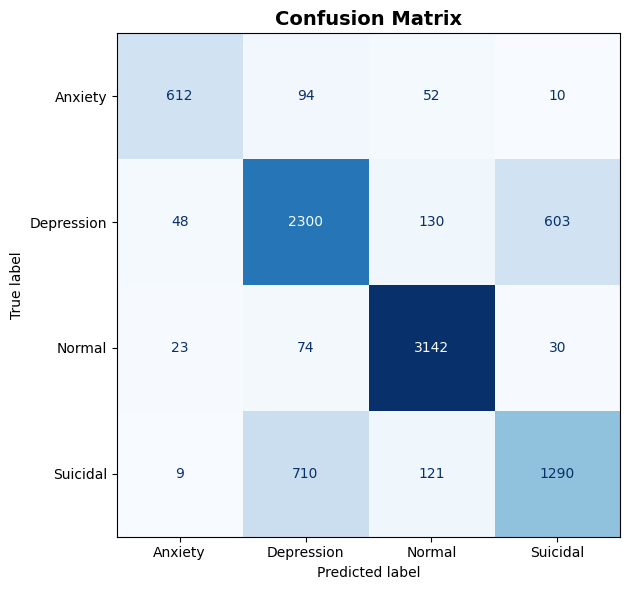

✅ Saved!


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved!")

In [10]:
import joblib

joblib.dump({
    "clf": svm_cal,
    "label_encoder": le,
}, "/kaggle/working/mental_health_model.pkl")

print("✅ Model saved → /kaggle/working/mental_health_model.pkl")

✅ Model saved → /kaggle/working/mental_health_model.pkl
